# 0154GBO, grain mill

RAMP calibration of this client, season by season and then month by month.

The cells read the committed results in `resultats/`. The replay cell runs the RAMP engine
again on the published input files and checks that it gives back the published profiles
exactly. To calibrate everything again from the meter data, see `src/run.py` (about fifteen
hours).

In [1]:
CLIENT = "0154GBO"

import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

REPO = Path.cwd().resolve().parents[1]      # repository root, two levels above notebooks/<type>/
sys.path.append(str(REPO / "src"))
import calibration as K

# Folders of the seasonal and monthly results
SEASONS = REPO / "resultats" / "reference_saison"
MONTHS = REPO / "resultats" / "calib_mois"


def results(folder):
    """Results of this client in a folder, one per target."""
    return [json.load(open(p)) for p in sorted(folder.glob(f"{CLIENT}__*.json"))]


def summary(ps):
    """One row per target: days, verdict, missed criteria, four key gaps, RAMP durations."""
    return pd.DataFrame([{"target": p["cible"], "days": p["jours_retenus"], "verdict": p["verdict"],
                          "missed criteria": ", ".join(p["manques"]) or "-",
                          "NRMSE (%)": round(100 * p["mesures"]["NRMSE"], 1),
                          "harmonics (%)": round(100 * p["mesures"]["FFT_err"], 1),
                          "energy (%)": round(p["mesures"]["err_E_pct"], 1),
                          "peak time (h)": p["mesures"]["ECART_PICS_h"],
                          "func_cycle (min)": p["func_cycle"], "period (min)": p["L_etoile"]}
                         for p in ps])


def show(folder, pattern):
    """Every figure of a folder matching the pattern, in file order."""
    for path in sorted(folder.glob(pattern)):
        display(Image(filename=str(path), width=900))


# Results of this client, season by season and month by month
seasons, months = results(SEASONS), results(MONTHS)
print(f"{len(seasons)} seasonal targets and {len(months)} monthly targets for {CLIENT}")

4 seasonal targets and 11 monthly targets for 0154GBO


## Seasons

Verdict of the validation contract: *validee* (every criterion met), *rejetee* (at least one
criterion missed) or *non verifiable* (the days of the target are too few or too scattered to
judge a model at the 10 % level). The gaps are between the mean measured profile and the mean
profile simulated by RAMP.

In [2]:
summary(seasons)

,target,days,verdict,missed criteria,NRMSE (%),harmonics (%),energy (%),peak time (h),func_cycle (min),period (min)
0,Mai,36,rejetee,"err_P_pct, ECART_PICS_h",7.3,10.6,0.9,3.00,15,30
1,Octobre,29,validee,-,5.9,10.3,-3.2,0.25,15,60
2,Saison des pluies,138,validee,-,4.8,8.8,-0.8,0.50,15,30
3,Saison seche,177,rejetee,ECART_PICS_h,6.0,8.4,-2.6,3.00,30,30


### Retained RAMP parameters

Windows and cycle ranges, share of time running, durations, and the daily peaks against the
nameplate power entered in RAMP.

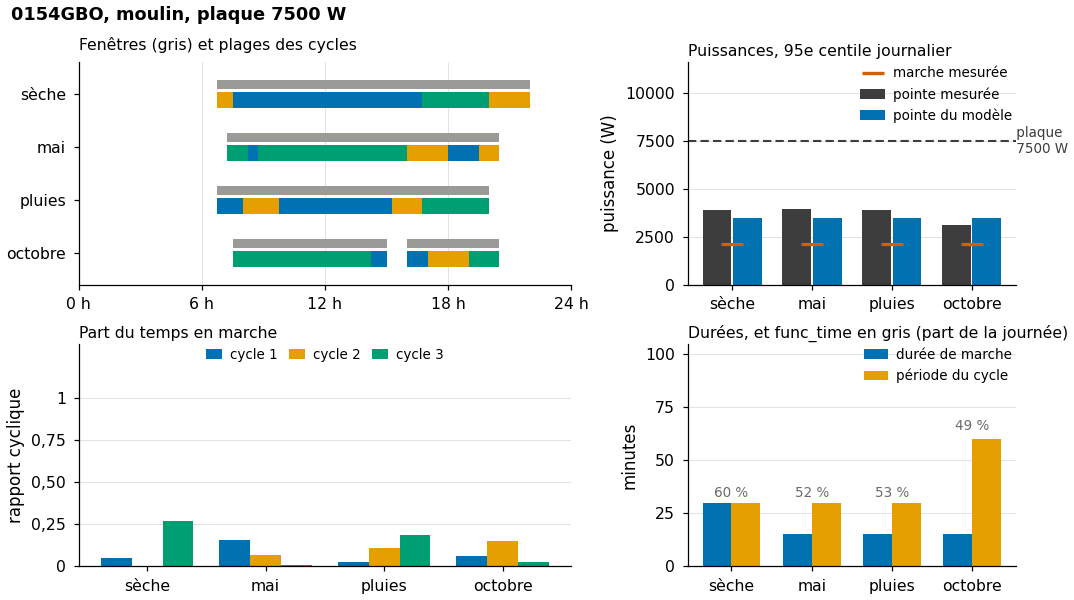

In [3]:
show(SEASONS / "publication" / "figures", f"parametres_{CLIENT}_*.png")

### Measured and simulated profiles

Grey line: mean measured profile; blue line: RAMP model; grey band: 90 % band of the noise of the
mean. Lower panel: model minus measurement, relative to that noise.

**Mai**

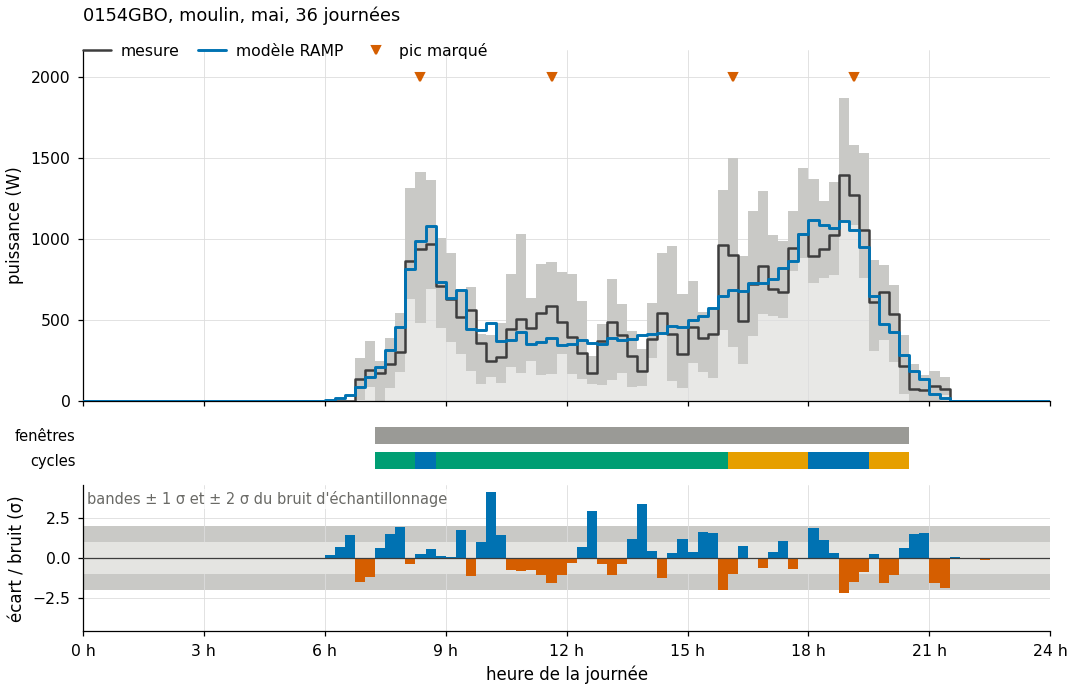

**Octobre**

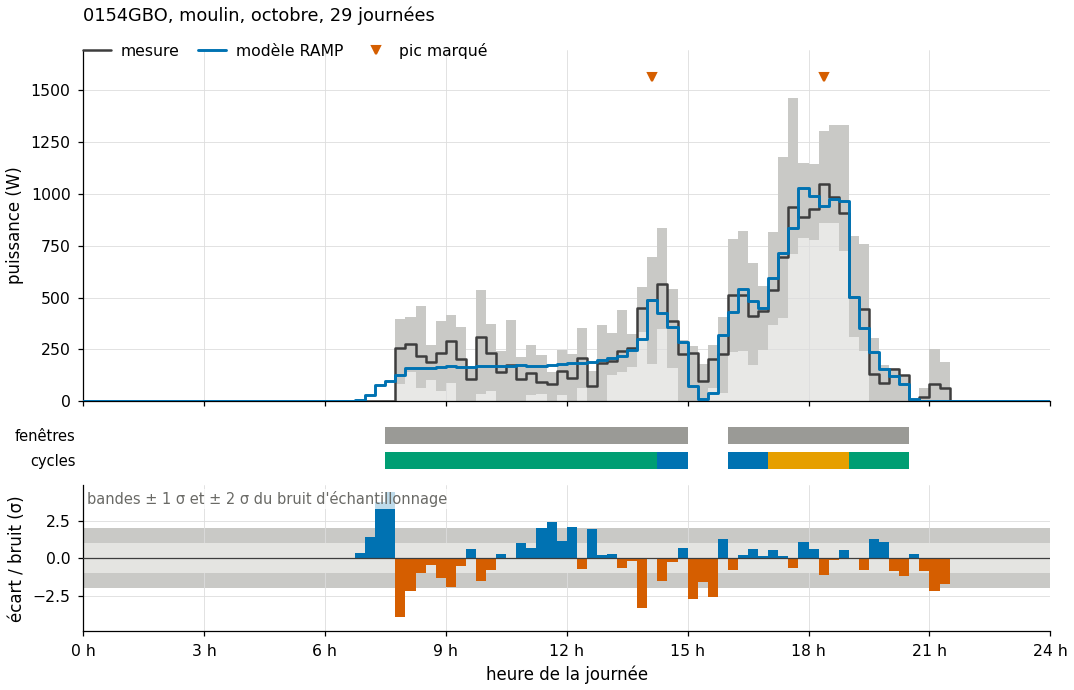

**Saison des pluies**

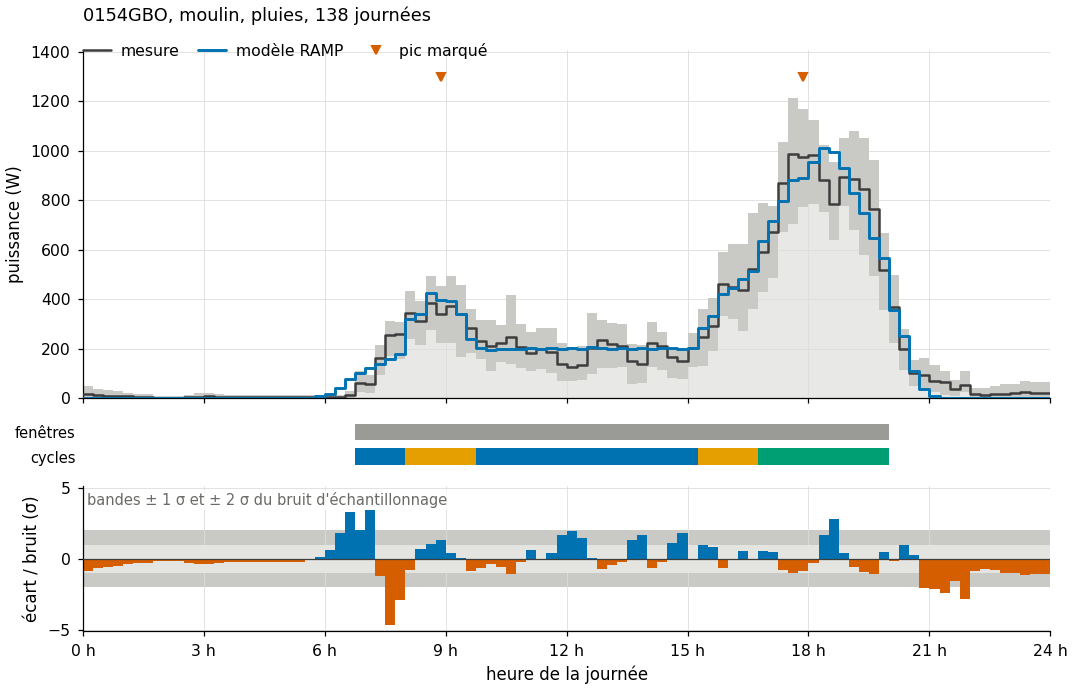

**Saison seche**

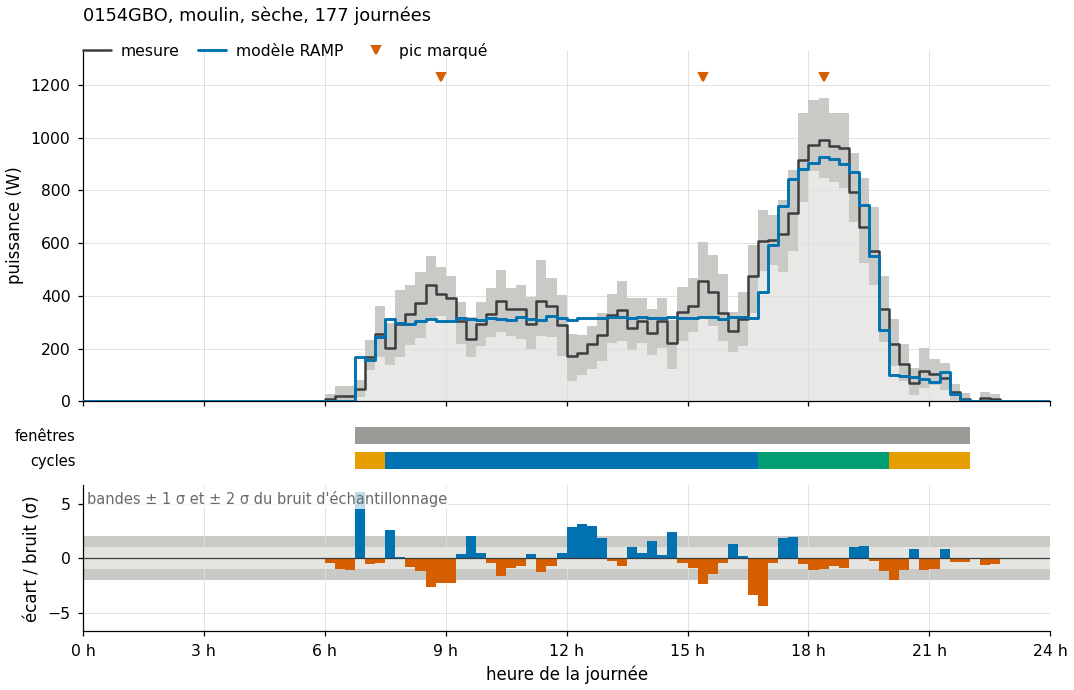

In [4]:
# Publication figure of each seasonal target
for p in seasons:
    display(Markdown(f"**{p['cible']}**"))
    show(SEASONS / "publication" / "figures" / "cibles", f"{p['nom']}.png")

### RAMP input files

Each file declares the appliance as a RAMP user would write it, with the nameplate power as
`power` and `p_i1`. It runs on its own: `python resultats/reference_saison/entrees_ramp/<target>.py`.

In [5]:
# RAMP declaration of each seasonal target, without the stand-alone runner
for p in seasons:
    display(Markdown(f"**{p['cible']}**"))
    print((SEASONS / "entrees_ramp" / f"{p['nom']}.py").read_text().split("if __name__")[0])

**Mai**

# 0154GBO, Mai : moulin à grains, plaque 7500 W. Parametres RAMP calibres le 19/09/2026 (plan d'audit, etape 3).


def declarer(user):
    app = user.add_appliance(name="grain_milling", number=1, power=7500,
        num_windows=1, func_time=750, func_cycle=15,
        fixed="yes", fixed_cycle=3, continuous_duty_cycle=1,
        occasional_use=1.000, flat="no", thermal_p_var=0,
        time_fraction_random_variability=0, pref_index=0, wd_we_type=2)
    app.windows(random_var_w=0.1, window_1=[435, 1230])
    app.specific_cycle(1, p_11=7500, t_11=7, p_12=12.0, t_12=39, r_c1=0, cw11=[495, 525], cw12=[1080, 1170])
    app.specific_cycle(2, p_21=7500, t_21=2, p_22=12.0, t_22=28, r_c2=0, cw21=[960, 1080], cw22=[1170, 1230])
    app.specific_cycle(3, p_31=7500, t_31=1, p_32=12.0, t_32=114, r_c3=0, cw31=[435, 495], cw32=[525, 960])





**Octobre**

# 0154GBO, Octobre : moulin à grains, plaque 7500 W. Parametres RAMP calibres le 19/09/2026 (plan d'audit, etape 3).


def declarer(user):
    app = user.add_appliance(name="grain_milling", number=1, power=7500,
        num_windows=2, func_time=705, func_cycle=15,
        fixed="yes", fixed_cycle=3, continuous_duty_cycle=0,
        occasional_use=1.000, flat="no", thermal_p_var=0,
        time_fraction_random_variability=0, pref_index=0, wd_we_type=2)
    app.windows(random_var_w=0.1, window_1=[450, 900], window_2=[960, 1230])
    app.specific_cycle(1, p_11=7500, t_11=4, p_12=12.0, t_12=59, r_c1=0, cw11=[855, 900], cw12=[960, 1020])
    app.specific_cycle(2, p_21=7500, t_21=6, p_22=12.0, t_22=34, r_c2=0, cw21=[1020, 1140])
    app.specific_cycle(3, p_31=7500, t_31=1, p_32=12.0, t_32=43, r_c3=0, cw31=[450, 855], cw32=[1140, 1230])





**Saison des pluies**

# 0154GBO, Saison des pluies : moulin à grains, plaque 7500 W. Parametres RAMP calibres le 19/09/2026 (plan d'audit, etape 3).


def declarer(user):
    app = user.add_appliance(name="grain_milling", number=1, power=7500,
        num_windows=1, func_time=765, func_cycle=15,
        fixed="yes", fixed_cycle=3, continuous_duty_cycle=1,
        occasional_use=1.000, flat="no", thermal_p_var=0,
        time_fraction_random_variability=0, pref_index=0, wd_we_type=2)
    app.windows(random_var_w=0.1, window_1=[405, 1200])
    app.specific_cycle(1, p_11=7500, t_11=1, p_12=12.0, t_12=36, r_c1=0, cw11=[405, 480], cw12=[585, 915])
    app.specific_cycle(2, p_21=7500, t_21=3, p_22=12.0, t_22=24, r_c2=0, cw21=[480, 585], cw22=[915, 1005])
    app.specific_cycle(3, p_31=7500, t_31=6, p_32=12.0, t_32=27, r_c3=0, cw31=[1005, 1200])





**Saison seche**

# 0154GBO, Saison seche : moulin à grains, plaque 7500 W. Parametres RAMP calibres le 19/09/2026 (plan d'audit, etape 3).


def declarer(user):
    app = user.add_appliance(name="grain_milling", number=1, power=7500,
        num_windows=1, func_time=870, func_cycle=30,
        fixed="yes", fixed_cycle=3, continuous_duty_cycle=1,
        occasional_use=1.000, flat="no", thermal_p_var=0,
        time_fraction_random_variability=0, pref_index=0, wd_we_type=2)
    app.windows(random_var_w=0.0, window_1=[405, 1320])
    app.specific_cycle(1, p_11=7500, t_11=1, p_12=0.0, t_12=21, r_c1=0, cw11=[450, 1005])
    app.specific_cycle(2, p_21=7500, t_21=1, p_22=0.0, t_22=900, r_c2=0, cw21=[405, 450], cw22=[1200, 1320])
    app.specific_cycle(3, p_31=7500, t_31=6, p_32=0.0, t_32=16, r_c3=0, cw31=[1005, 1200])





### Replay

The RAMP engine is run again on each input file with the check seeds (20 runs of 480 days).
It must give back the published profile exactly. A few seconds per target.

In [6]:
# Replay of each seasonal target with the check seeds, compared with the published profile
for p in seasons:
    text = (SEASONS / "entrees_ramp" / f"{p['nom']}.py").read_text()
    profile = K.simulate(text, K.SEEDS_CHECK[0], 20)
    published = np.load(SEASONS / f"{p['nom']}_profil.npy")
    print(f"{p['cible']:<40} identical to the published profile: {np.array_equal(profile, published)}")

Mai                                      identical to the published profile: True


Octobre                                  identical to the published profile: True


Saison des pluies                        identical to the published profile: True


Saison seche                             identical to the published profile: True


## Months

One target per calendar month and fleet configuration. The duration `func_cycle` is inherited
from the seasonal target of the same client and season; everything else is searched month by
month.

In [7]:
summary(months)

,target,days,verdict,missed criteria,NRMSE (%),harmonics (%),energy (%),peak time (h),func_cycle (min),period (min)
0,Aout,21,rejetee,"ECART_PICS_h, ELM_1h",10.2,9.9,-5.5,2.50,15,30
1,Avril,46,rejetee,"FFT_err, ECART_PICS_h",7.7,22.2,-0.3,3.00,15,30
2,Fevrier,38,rejetee,ECART_PICS_h,8.9,15.6,0.9,3.00,30,60
3,Janvier,21,rejetee,ECART_PICS_h,9.4,11.5,-0.4,2.75,30,30
4,Juillet,44,validee,-,8.2,10.0,-2.5,1.25,15,15
5,Juin,49,validee,-,6.0,9.5,-1.8,1.00,15,30
6,Mai,36,rejetee,"err_P_pct, ECART_PICS_h",7.3,10.6,0.9,3.00,15,30
7,Mars,41,rejetee,ECART_PICS_h,8.5,19.2,-1.1,3.00,15,15
8,Novembre,30,rejetee,ECART_PICS_h,6.1,7.1,-0.1,2.25,30,15
9,Octobre,29,validee,-,5.9,10.3,-3.2,0.25,15,60


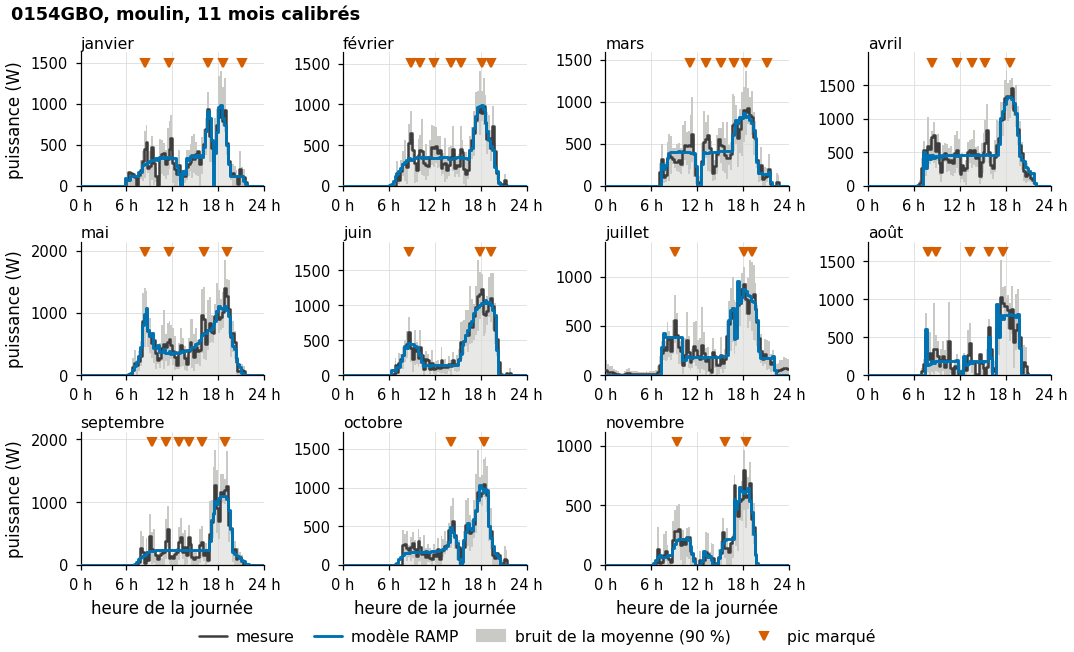

In [8]:
show(MONTHS / "publication" / "figures", f"multiples_client_{CLIENT}.png")

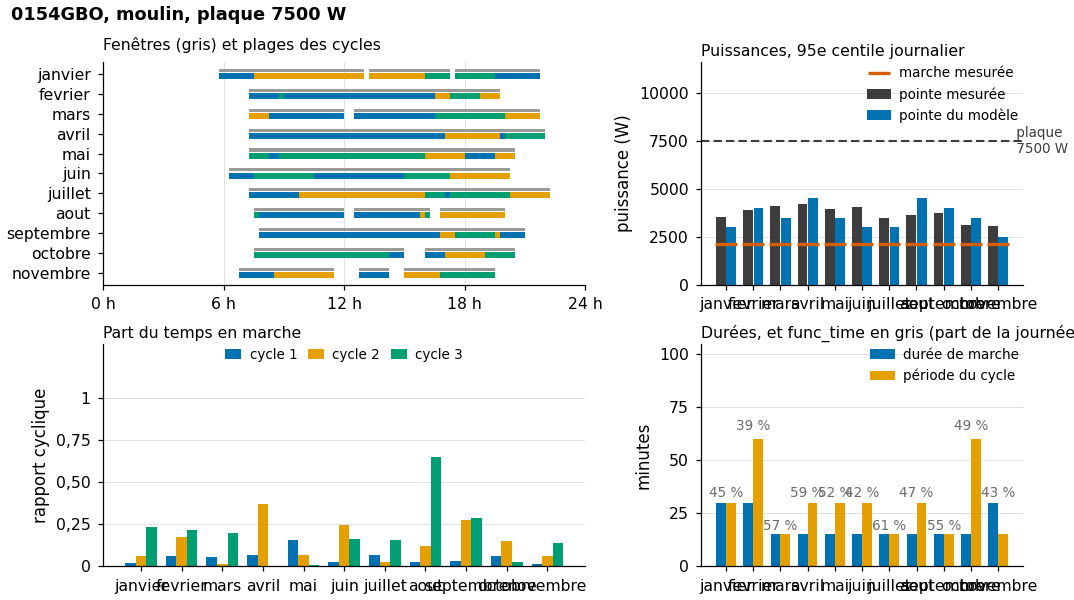

In [9]:
show(MONTHS / "publication" / "figures", f"parametres_{CLIENT}_*.png")